# 🛍️ AI-Powered Product Image Retrieval System
## Visual Search with EfficientNetB0 + Transformer Captioning

> **Goal:** Upload any product image → get an AI-generated caption → find the most visually similar products using cosine similarity on EfficientNetB0 embeddings.

---

### 📋 Notebook Sections
| # | Section |
|---|---------|
| 1 | Install & Imports |
| 2 | Global Configuration |
| 3 | Load Dataset |
| 4 | Model Architecture (EfficientNetB0 + Transformer) |
| 5 | Load Pretrained Model |
| 6 | Image Preprocessing Utilities |
| 7 | Caption Generation |
| 8 | Feature Extraction (Embedding Engine) |
| 9 | Generate & Cache Product Embeddings |
| 10 | Upload User Image |
| 11 | Cosine Similarity Search |
| 12 | Retrieve Top Matches |
| 13 | Visualization & Final Results |


## Section 1 — Install & Imports

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import os
import re
import json
import pickle
import textwrap
import warnings
from pathlib import Path
from io import BytesIO

warnings.filterwarnings("ignore")

# ── Numerical & Data ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Deep Learning ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.text import Tokenizer, tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# ── Image ─────────────────────────────────────────────────────────────────────
from PIL import Image
import requests

# ── ML ────────────────────────────────────────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.image as mpimg

# ── Optional: FAISS for fast similarity search ────────────────────────────────
try:
    import faiss
    FAISS_AVAILABLE = True
    print("✅ FAISS available — fast ANN search enabled")
except ImportError:
    FAISS_AVAILABLE = False
    print("ℹ️  FAISS not installed — using sklearn cosine similarity (still fast)")

print(f"\n✅ TensorFlow {tf.__version__}")
print(f"✅ NumPy      {np.__version__}")
print(f"✅ Pandas     {pd.__version__}")

✅ FAISS available — fast ANN search enabled

✅ TensorFlow 2.21.0
✅ NumPy      2.4.4
✅ Pandas     3.0.2


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURE THESE PATHS FOR YOUR ENVIRONMENT
# ══════════════════════════════════════════════════════════════════════════════

CSV_PATH   = "cleaned_data_final.csv"   # output of preprocessing.ipynb
IMG_DIR = Path(r"E:\AMANY1\ChatBot AI Fashion Assistant\scraping\data\images_fresh")            # folder containing {product_id}.jpg
MODELS_DIR = Path("saved_models")
LOGS_DIR   = Path("logs")       # cached embeddings storage
EMBEDDINGS_DIR = Path("embeddings_cache")       # cached embeddings storage

MODELS_DIR.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

# ── Paths to saved artifacts ──────────────────────────────────────────────────
MODEL4_WEIGHTS   = MODELS_DIR / "model4_efficientnetb0_transformer_best.keras"
TOKENIZER_PATH   = MODELS_DIR / "tokenizer.json"
EMBEDDINGS_PATH  = EMBEDDINGS_DIR / "product_embeddings.npy"
PRODUCT_IDS_PATH = EMBEDDINGS_DIR / "product_ids.npy"

# ── Image settings ────────────────────────────────────────────────────────────
IMG_SIZE      = (224, 224)
IMG_CHANNELS  = 3

# ── Captioning model hyperparameters (must match training) ────────────────────
VOCAB_SIZE    = 4000
MAX_SEQ_LEN   = 32
EMBED_DIM     = 512          # word embedding dim
UNITS         = 512          # transformer / LSTM units
ATTN_UNITS    = 256
NUM_HEADS     = 4
FF_DIM        = 512
DROPOUT_RATE  = 0.3

# ── Retrieval settings ────────────────────────────────────────────────────────
TOP_K         = 5            # number of similar products to return

# ── CNN feature dimension ─────────────────────────────────────────────────────
EFFNET_FEATURE_DIM = 1280    # EfficientNetB0 GlobalAvgPool output

print("✅ Configuration loaded")
print(f"   CSV      : {CSV_PATH}")
print(f"   IMG_DIR  : {IMG_DIR}")
print(f"   Model    : {MODEL4_WEIGHTS}")
print(f"   Tokenizer: {TOKENIZER_PATH}")
print(f"   TOP_K    : {TOP_K}") 
print(f"   EMBEDDINGS_DIR  : {EMBEDDINGS_DIR}")

✅ Configuration loaded
   CSV      : cleaned_data_final.csv
   IMG_DIR  : E:\AMANY1\ChatBot AI Fashion Assistant\scraping\data\images_fresh
   Model    : saved_models\model4_efficientnetb0_transformer_best.keras
   Tokenizer: saved_models\tokenizer.json
   TOP_K    : 5
   EMBEDDINGS_DIR  : embeddings_cache


## Section 3 — Load Dataset

In [3]:
# ── Load product dataset ─────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH, low_memory=False)

print(f"Dataset shape   : {df.shape}")
print(f"Columns         : {df.columns.tolist()}")
print()

# ── Keep only rows with valid image URLs ──────────────────────────────────────
df = df[df["img_url_valid"] == True].reset_index(drop=True)
print(f"Rows with valid images: {len(df):,}")

# ── Quick preview ─────────────────────────────────────────────────────────────
print()
print("── Sample rows ──────────────────────────────────────────────────────────")
display_cols = ["product_id", "title_clean", "category_clean", "gender_clean",
                "price_egp", "price_bucket", "primary_color", "product_url", "img_url"]
df[display_cols].head(3)

Dataset shape   : (5281, 44)
Columns         : ['product_id', 'url', 'path', 'title', 'price', 'category', 'gender', 'img_url', 'product_url', 'price_min_egp', 'price_max_egp', 'price_egp', 'is_price_range', 'price_normalized', 'price_bucket', 'category_clean', 'category_group', 'category_id', 'category_group_id', 'gender_clean', 'gender_id', 'title_clean', 'title_search', 'title_word_count', 'title_char_count', 'title_quality_flag', 'colors', 'primary_color', 'color_count', 'colors_str', 'pattern', 'pattern_clean', 'has_pattern', 'pattern_group', 'brand', 'is_known_brand', 'sleeve_type', 'fit_type', 'materials', 'materials_str', 'metadata_text', 'img_url_valid', 'img_url_reason', 'url_format_ok']

Rows with valid images: 5,281

── Sample rows ──────────────────────────────────────────────────────────


,product_id,title_clean,category_clean,gender_clean,price_egp,price_bucket,primary_color,product_url,img_url
0,0,Decathlon Women's Relaxation Yoga Fleece Sweat...,hoodies & sweatshirts,women,1049.0,premium,mottled grey,https://www.jumia.com.eg/decathlon-womens-rela...,https://eg.jumia.is/unsafe/fit-in/300x300/filt...
1,1,Decathlon Women's Fitness Sweatshirt 100 - Pink,hoodies & sweatshirts,women,699.0,mid-range,pink,https://www.jumia.com.eg/decathlon-womens-fitn...,https://eg.jumia.is/unsafe/fit-in/300x300/filt...
2,2,Decathlon Women's Fitness Hoodie 520 - Pink Qu...,hoodies & sweatshirts,women,1739.0,premium,pink quartz,https://www.jumia.com.eg/decathlon-womens-fitn...,https://eg.jumia.is/unsafe/fit-in/300x300/filt...


In [4]:
# ── Build structured captions for each product ───────────────────────────────
# (Same logic as training notebook — MUST match exactly)

START_TOKEN = "<start>"
END_TOKEN   = "<end>"
UNK_TOKEN   = "<unk>"
PAD_TOKEN   = "<pad>"

def build_caption(row: pd.Series) -> str:
    """Build a structured text caption from product metadata."""
    title = str(row.get("title_clean", "")).strip()
    title = re.sub(r"[\u0600-\u06FF]+", "", title)
    title = re.sub(r"\s+", " ", title).strip()
    title = " ".join(title.split()[:15])       # cap at 15 words

    parts = [title]

    color = str(row.get("primary_color", "")).strip().lower()
    if color and color not in ("unknown", "nan", ""):
        parts.append(color)

    cat = str(row.get("category_clean", "")).strip().lower()
    if cat and cat not in ("unknown", "nan", ""):
        parts.append(cat)

    gender = str(row.get("gender_clean", "")).strip().lower()
    if gender and gender not in ("unknown", "nan", ""):
        parts.append(gender)

    bucket = str(row.get("price_bucket", "")).strip().lower()
    if bucket and bucket not in ("unknown", "nan", ""):
        parts.append(bucket)

    price = str(row.get("price_egp", "")).strip()
    if price and price not in ("nan", ""):
        parts.append(f"egp {price}")

    caption = re.sub(r"\s+", " ", " ".join(parts)).strip()
    return f"{START_TOKEN} {caption} {END_TOKEN}"

df["caption"] = df.apply(build_caption, axis=1)

print(f"✅ Captions built: {len(df):,}")
print()
print("── Sample captions ──────────────────────────────────────────────────────")
for _, row in df[["title_clean", "caption"]].head(3).iterrows():
    print(f"  Title  : {row['title_clean'][:60]}")
    print(f"  Caption: {row['caption'][:80]}")
    print()

✅ Captions built: 5,281

── Sample captions ──────────────────────────────────────────────────────
  Title  : Decathlon Women's Relaxation Yoga Fleece Sweatshirt - Mottle
  Caption: <start> Decathlon Women's Relaxation Yoga Fleece Sweatshirt - Mottled Grey mottl

  Title  : Decathlon Women's Fitness Sweatshirt 100 - Pink
  Caption: <start> Decathlon Women's Fitness Sweatshirt 100 - Pink pink hoodies & sweatshir

  Title  : Decathlon Women's Fitness Hoodie 520 - Pink Quartz
  Caption: <start> Decathlon Women's Fitness Hoodie 520 - Pink Quartz pink quartz hoodies &



## Section 4 — Model Architecture (EfficientNetB0 + Transformer)

The captioning model consists of:
- **EfficientNetB0 Encoder**: Extracts spatial features `(B, 49, 1280)` from images, projected to `(B, 49, 512)`
- **Positional Embedding**: Sinusoidal encodings for caption tokens
- **Transformer Decoder**: 2× decoder blocks with causal self-attention + cross-attention over image features
- **Output head**: Softmax over vocabulary


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CUSTOM LAYERS — must match training notebook exactly
# ══════════════════════════════════════════════════════════════════════════════

class TransformerDecoderBlock(layers.Layer):
    """
    One Transformer decoder block:
    1. Masked Multi-Head Self-Attention  (causal)
    2. Cross-Attention                   (attends to CNN image features)
    3. Feed-Forward Network              (GELU activation)
    4. Add & LayerNorm after each sublayer
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim    = ff_dim
        key_dim = embed_dim // num_heads   # 512 // 4 = 128 per head

        self.attn1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, name="self_attn")
        self.attn2 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, name="cross_attn")
        self.ff1   = layers.Dense(ff_dim, activation="gelu", name="ff1")
        self.ff2   = layers.Dense(embed_dim, name="ff2")
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)
        self.drop3 = layers.Dropout(dropout)

    def call(self, x, encoder_output, training=False, look_ahead_mask=None):
        attn1_out, _ = self.attn1(x, x, x, attention_mask=look_ahead_mask,
                                  return_attention_scores=True, training=training)
        attn1_out = self.drop1(attn1_out, training=training)
        out1 = self.norm1(x + attn1_out)

        attn2_out, _ = self.attn2(out1, encoder_output, encoder_output,
                                  return_attention_scores=True, training=training)
        attn2_out = self.drop2(attn2_out, training=training)
        out2 = self.norm2(out1 + attn2_out)

        ff_out = self.ff2(self.ff1(out2))
        ff_out = self.drop3(ff_out, training=training)
        return self.norm3(out2 + ff_out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"embed_dim": self.embed_dim, "num_heads": self.num_heads, "ff_dim": self.ff_dim})
        return cfg


class PositionalEmbedding(layers.Layer):
    """
    Token embeddings + sinusoidal positional encodings.
    Embeddings scaled by sqrt(embed_dim) before adding positional signal.
    """
    def __init__(self, vocab_size, embed_dim, max_len, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.embed_dim  = embed_dim
        self.max_len    = max_len
        self.token_emb  = layers.Embedding(vocab_size, embed_dim, mask_zero=False)
        self.pos_enc    = self._build_pos_enc(max_len, embed_dim)

    def _build_pos_enc(self, max_len, d):
        pos  = np.arange(max_len)[:, None]
        dims = np.arange(d)[None, :]
        ang  = pos / np.power(10000, (2 * (dims // 2)) / np.float32(d))
        ang[:, 0::2] = np.sin(ang[:, 0::2])
        ang[:, 1::2] = np.cos(ang[:, 1::2])
        return tf.cast(ang[None, :, :], tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        tok = self.token_emb(x) * tf.math.sqrt(tf.cast(self.embed_dim, tf.float32))
        return tok + self.pos_enc[:, :seq_len, :]

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"vocab_size": self.vocab_size, "embed_dim": self.embed_dim, "max_len": self.max_len})
        return cfg


def get_causal_mask(seq_len):
    """Lower-triangular boolean mask — True = allow attention."""
    return tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)

print("✅ Custom layers defined: TransformerDecoderBlock, PositionalEmbedding, get_causal_mask")


✅ Custom layers defined: TransformerDecoderBlock, PositionalEmbedding, get_causal_mask


In [6]:
# ── EfficientNetB0 feature extractor ─────────────────────────────────────────

def build_efficientnetb0_extractor(spatial: bool = False):
    """
    EfficientNetB0 (ImageNet weights) feature extractor.

    spatial=True  → returns (B, 49, 1280)  for Transformer cross-attention
    spatial=False → returns (B, 1280)       for embedding/similarity search
    """
    base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, IMG_CHANNELS)
    )
    for layer in base.layers[:-20]:
        layer.trainable = False
    for layer in base.layers[-20:]:
        layer.trainable = True

    inp          = base.input
    spatial_feat = base.get_layer("top_activation").output   # (7, 7, 1280)

    if spatial:
        out = layers.Reshape((49, 1280))(spatial_feat)
        return Model(inp, out, name="EfficientNetB0_spatial")
    else:
        out = layers.GlobalAveragePooling2D()(spatial_feat)
        return Model(inp, out, name="EfficientNetB0_vector")


def build_model4_efficientnet_transformer(
        vocab_size   = VOCAB_SIZE,
        embed_dim    = UNITS,
        num_heads    = NUM_HEADS,
        ff_dim       = FF_DIM,
        num_layers   = 2,
        dropout_rate = DROPOUT_RATE,
) -> Model:
    """
    Model 4: EfficientNetB0 (CNN Encoder) + Transformer Decoder.
    Inputs : [image (224,224,3), caption_tokens (31,)]
    Output : softmax over vocabulary  (B, 31, vocab_size)
    """
    img_input     = Input(shape=(*IMG_SIZE, IMG_CHANNELS), name="image_input")
    caption_input = Input(shape=(MAX_SEQ_LEN - 1,),        name="caption_input")

    # ── CNN Encoder ───────────────────────────────────────────────────────────
    cnn          = build_efficientnetb0_extractor(spatial=True)
    spatial_feat = cnn(img_input)                              # (B, 49, 1280)

    img_enc = layers.Dense(embed_dim, activation="relu",
                        kernel_regularizer=l2(1e-4), name="img_proj")(spatial_feat)
    img_enc = layers.LayerNormalization(epsilon=1e-6, name="img_layernorm")(img_enc)
    img_enc = layers.Dropout(dropout_rate, name="img_drop")(img_enc)

    # ── Caption Embedding + Positional Encoding ───────────────────────────────
    dec_in = PositionalEmbedding(vocab_size, embed_dim, MAX_SEQ_LEN,
                                name="pos_embedding")(caption_input)
    dec_in = layers.Dropout(dropout_rate, name="cap_drop")(dec_in)

    # ── Causal Mask ───────────────────────────────────────────────────────────
    causal_mask = get_causal_mask(MAX_SEQ_LEN - 1)

    # ── Transformer Decoder Blocks ────────────────────────────────────────────
    x = dec_in
    for i in range(num_layers):
        x = TransformerDecoderBlock(
            embed_dim=embed_dim, num_heads=num_heads,
            ff_dim=ff_dim, dropout=dropout_rate,
            name=f"transformer_block_{i}"
        )(x, img_enc, look_ahead_mask=causal_mask)

    # ── Output Head ───────────────────────────────────────────────────────────
    x      = layers.Dropout(dropout_rate, name="final_drop")(x)
    output = layers.Dense(vocab_size, activation="softmax",
                        kernel_regularizer=l2(1e-4), name="output_softmax")(x)

    return Model(inputs=[img_input, caption_input],
                outputs=output,
                name="Model4_EfficientNetB0_Transformer")


print("✅ build_efficientnetb0_extractor() defined")
print("✅ build_model4_efficientnet_transformer() defined")


✅ build_efficientnetb0_extractor() defined
✅ build_model4_efficientnet_transformer() defined


## Section 5 — Load Pretrained Model & Tokenizer

In [7]:
# ── Load tokenizer ───────────────────────────────────────────────────────────
if TOKENIZER_PATH.exists():
    with open(TOKENIZER_PATH, "r") as f:
        tokenizer_json = json.load(f)
    tokenizer = tokenizer_from_json(tokenizer_json)
    print(f"✅ Tokenizer loaded from {TOKENIZER_PATH}")
else:
    # ── Rebuild tokenizer from dataset captions ───────────────────────────────
    print(f"⚠️  Tokenizer file not found at {TOKENIZER_PATH}")
    print("    Rebuilding tokenizer from dataset captions...")
    tokenizer = Tokenizer(
        num_words=VOCAB_SIZE,
        oov_token=UNK_TOKEN,
        filters='!\"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n',
        lower=True
    )
    tokenizer.fit_on_texts(df["caption"].tolist())
    # Save for next time
    TOKENIZER_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(TOKENIZER_PATH, "w") as f:
        json.dump(tokenizer.to_json(), f)
    print(f"✅ Tokenizer rebuilt and saved → {TOKENIZER_PATH}")

# ── Token ID lookup ───────────────────────────────────────────────────────────
word_index = tokenizer.word_index
vocab_size  = min(len(word_index) + 1, VOCAB_SIZE)
index_word  = {v: k for k, v in word_index.items()}

START_ID = tokenizer.word_index.get(START_TOKEN, 1)
END_ID   = tokenizer.word_index.get(END_TOKEN,   2)
UNK_ID   = tokenizer.word_index.get(UNK_TOKEN,   3)
PAD_ID   = 0

print(f"\n   Vocabulary size : {vocab_size:,}")
print(f"   START_ID        : {START_ID}")
print(f"   END_ID          : {END_ID}")
print(f"   UNK_ID          : {UNK_ID}")

✅ Tokenizer loaded from saved_models\tokenizer.json

   Vocabulary size : 3,837
   START_ID        : 2
   END_ID          : 4
   UNK_ID          : 1


In [8]:
# ── Build model4 architecture and load saved weights ─────────────────────────
# Note: we rebuild architecture then load_weights() — safer than load_model()
# for custom layer models with Functional API.

tf.keras.backend.clear_session()

captioning_model = build_model4_efficientnet_transformer(vocab_size=vocab_size)

if MODEL4_WEIGHTS.exists():
    captioning_model.load_weights(str(MODEL4_WEIGHTS))
    print(f"✅ Weights loaded from {MODEL4_WEIGHTS}")
else:
    print(f"⚠️  Weight file not found: {MODEL4_WEIGHTS}")
    print("    The model architecture is ready — please provide the trained .keras weights file.")
    print("    Inference cells will still run but will produce random outputs until weights are loaded.")

# ── Sanity check ─────────────────────────────────────────────────────────────
_d = np.zeros((1, *IMG_SIZE, IMG_CHANNELS), dtype=np.float32)
_c = np.zeros((1, MAX_SEQ_LEN - 1),         dtype=np.int32)
_o = captioning_model([_d, _c], training=False)
print(f"✅ Model forward pass OK — output shape: {_o.shape}")
print(f"   Parameters: {captioning_model.count_params():,}")


✅ Weights loaded from saved_models\model4_efficientnetb0_transformer_best.keras
✅ Model forward pass OK — output shape: (1, 31, 3837)
   Parameters: 13,898,656


## Section 6 — Image Preprocessing Utilities

> All image loading uses **EfficientNet preprocessing** — scaling to `[0, 255]` float32 range, matching the training pipeline.


In [9]:
# ── Image loading & preprocessing utilities ──────────────────────────────────

def load_image_from_disk(product_id, img_dir=IMG_DIR, img_size=IMG_SIZE) -> np.ndarray:
    """
    Load image by product_id from disk.
    Returns float32 array (H, W, 3) in [0, 1]. Falls back to grey placeholder.
    """
    path = Path(img_dir) / f"{product_id}.jpg"
    try:
        if path.exists():
            with Image.open(path) as img:
                img = img.convert("RGB").resize(img_size, Image.BILINEAR)
                return np.array(img, dtype=np.float32) / 255.0
        else:
            return np.ones((*img_size, 3), dtype=np.float32) * 0.5
    except Exception:
        return np.ones((*img_size, 3), dtype=np.float32) * 0.5


def load_image_from_url(url: str, img_size=IMG_SIZE) -> np.ndarray:
    """
    Download and preprocess image from URL.
    Returns float32 array (H, W, 3) in [0, 1].
    """
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        img = img.resize(img_size, Image.BILINEAR)
        return np.array(img, dtype=np.float32) / 255.0
    except Exception as e:
        print(f"  ⚠️  URL load failed ({e}) — using placeholder")
        return np.ones((*img_size, 3), dtype=np.float32) * 0.5


def load_image_from_upload(file_path: str, img_size=IMG_SIZE) -> np.ndarray:
    try:
        with Image.open(file_path) as img:
            img = img.convert("RGB").resize(img_size, Image.BILINEAR)
            return np.array(img, dtype=np.float32) / 255.0
    except Exception as e:
        print(f"  ⚠️  Upload load failed ({e}) — using placeholder")
        return np.ones((*img_size, 3), dtype=np.float32) * 0.5


def preprocess_for_efficientnet(img_01: np.ndarray) -> np.ndarray:
    """
    Apply EfficientNet preprocessing.
    Input: float32 [0, 1] → Output: float32 preprocessed.
    """
    img_255 = img_01 * 255.0
    return np.array(
        tf.keras.applications.efficientnet.preprocess_input(img_255),
        dtype=np.float32
    )   # ← np.array() instead of .numpy() — works for both tensor and ndarray


print("✅ Image utilities defined:")
print("   load_image_from_disk()   — load by product_id")
print("   load_image_from_url()    — download from img_url")
print("   load_image_from_upload() — load uploaded file")
print("   preprocess_for_efficientnet() — EfficientNet preprocessing")

✅ Image utilities defined:
   load_image_from_disk()   — load by product_id
   load_image_from_url()    — download from img_url
   load_image_from_upload() — load uploaded file
   preprocess_for_efficientnet() — EfficientNet preprocessing


## Section 7 — Caption Generation

> Uses **greedy decoding** (auto-regressive, token-by-token) with the trained EfficientNetB0 + Transformer model.

In [10]:
# ── Greedy caption generator ─────────────────────────────────────────────────

def generate_caption(model, img_01: np.ndarray,
                    max_len: int = MAX_SEQ_LEN,
                    verbose: bool = False) -> str:
    """
    Auto-regressive greedy decoding for image captioning.

    Steps:
    1. Preprocess image with EfficientNet pipeline
    2. Start with [START_ID]
    3. Feed (image, current_tokens) → model → next token logits
    4. Append argmax token, repeat until END_ID or max_len

    Args:
        model   : trained EfficientNetB0 + Transformer model
        img_01  : float32 image array in [0, 1], shape (H, W, 3)
        max_len : maximum caption length (tokens)
        verbose : if True, print token-by-token decoding

    Returns:
        Generated caption string (without special tokens)
    """
    # Preprocess using the same pipeline as training
    img_255 = img_01 * 255.0
    img_pre = tf.keras.applications.efficientnet.preprocess_input(img_255)  # fixed
    img_pre = np.expand_dims(np.array(img_pre, dtype=np.float32), 0)        # (1,224,224,3)

    token_seq = [START_ID]

    for step_i in range(max_len - 1):
        # Pad current sequence to MAX_SEQ_LEN - 1
        padded = pad_sequences(
            [token_seq], maxlen=MAX_SEQ_LEN - 1, padding="post"
        )

        # Forward pass through captioning model
        preds = model.predict([img_pre, padded], verbose=0)    # (1, 31, vocab_size)

        # Get prediction at current step position
        pos     = min(len(token_seq) - 1, MAX_SEQ_LEN - 2)
        next_id = int(np.argmax(preds[0, pos, :]))

        if verbose:
            word = index_word.get(next_id, "<unk>")
            print(f"  step {step_i:2d} → token {next_id:4d} = '{word}'")

        if next_id == END_ID:
            break

        token_seq.append(next_id)

    # Decode token IDs → words (skip special tokens)
    words = []
    for tid in token_seq[1:]:
        word = index_word.get(tid, "")
        if word and word not in (START_TOKEN, END_TOKEN, UNK_TOKEN, PAD_TOKEN, ""):
            words.append(word)

    return " ".join(words)


print("✅ generate_caption() defined")
print()

# ── Quick smoke test ──────────────────────────────────────────────────────────
# captioning_model must be loaded before running this
try:
    _dummy_img = np.random.rand(*IMG_SIZE, 3).astype(np.float32)
    _test_cap  = generate_caption(captioning_model, _dummy_img)
    print("── Quick smoke test ──────────────────────────────────────────────────")
    print(f"   Smoke test caption (random image): '{_test_cap[:80]}'")
    print("   (Load real weights for meaningful output)")
except NameError:
    print("⚠️  captioning_model not loaded yet — run the model loading cell first")
    print("   generate_caption() is defined and ready to use after loading.")

✅ generate_caption() defined

── Quick smoke test ──────────────────────────────────────────────────
   Smoke test caption (random image): 'a modern and a zipper closure denim skirt skirts women mid range egp 799 0'
   (Load real weights for meaningful output)


In [11]:
# Test on a real product image from the dataset
sample_row = df.iloc[0]
print(f"Testing on: {sample_row['title_clean'][:60]}")
print(f"Expected  : {sample_row['caption'][:80]}")

# Load real image
if (IMG_DIR / f"{sample_row['product_id']}.jpg").exists():
    real_img = load_image_from_disk(sample_row["product_id"])
else:
    real_img = load_image_from_url(sample_row["img_url"])

real_cap = generate_caption(captioning_model, real_img)
print(f"Generated : {real_cap}")

Testing on: Decathlon Women's Relaxation Yoga Fleece Sweatshirt - Mottle
Expected  : <start> Decathlon Women's Relaxation Yoga Fleece Sweatshirt - Mottled Grey mottl
Generated : decathlon women's fitness sweatshirt with a unique design hoodies sweatshirts women premium egp 899 0


## Section 8 — Feature Extraction (Embedding Engine)

> We build a **separate EfficientNetB0 vector extractor** (without the decoder) to generate compact `(1280,)` embeddings used for cosine similarity search.


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE EXTRACTOR — Reuses fine-tuned EfficientNetB0 from captioning model
# ══════════════════════════════════════════════════════════════════════════════
#
# WHY reuse from captioning_model instead of building fresh?
#   The EfficientNetB0 inside captioning_model was fine-tuned on your
#   Jumia Egypt fashion data during training (last 20 layers unfrozen).
#   Its weights learned fashion-specific features: textures, garment shapes,
#   color patterns, accessories — much better than raw ImageNet weights.
#
# HOW it works:
#   captioning_model contains an EfficientNetB0_spatial sub-model that outputs
#   (B, 49, 1280) — 49 spatial tokens from 7×7 grid.
#   We reshape (B, 49, 1280) → (B, 7, 7, 1280) then GlobalAvgPool → (B, 1280)
#   giving one compact 1280-dim embedding per image.
# ══════════════════════════════════════════════════════════════════════════════

# ── Step 1: Find the EfficientNetB0 sub-model inside captioning_model ─────────
effnet_submodel = None
for layer in captioning_model.layers:
    if "efficientnetb0" in layer.name.lower():
        effnet_submodel = layer
        break

if effnet_submodel is not None:
    print(f"✅ Found fine-tuned CNN: {effnet_submodel.name}")
    print(f"   Output shape: {effnet_submodel.output_shape}")  # (None, 49, 1280)
    USE_FINETUNED = True
else:
    print("⚠️  EfficientNetB0 sub-model not found in captioning_model")
    print("    Falling back to fresh ImageNet weights")
    USE_FINETUNED = False

# ── Step 2: Build embedding extractor ─────────────────────────────────────────
inp = Input(shape=(*IMG_SIZE, IMG_CHANNELS), name="image_input")

if USE_FINETUNED:
    # Reuse fine-tuned weights from captioning model
    # Output: (B, 49, 1280) — reshape to (B, 7, 7, 1280) then pool
    spatial_out = effnet_submodel(inp)                              # (B, 49, 1280)
    reshaped    = layers.Reshape((7, 7, 1280), name="reshape")(spatial_out)
    pooled      = layers.GlobalAveragePooling2D(name="gap")(reshaped)  # (B, 1280)
else:
    # Fallback: fresh EfficientNetB0 with ImageNet weights
    base        = EfficientNetB0(
        weights="imagenet", include_top=False,
        input_shape=(*IMG_SIZE, IMG_CHANNELS)
    )
    base.trainable = False
    feat_map    = base.get_layer("top_activation").output           # (B, 7, 7, 1280)
    pooled      = layers.GlobalAveragePooling2D(name="gap")(feat_map)
    inp         = base.input

embedding_extractor = Model(inp, pooled, name="effnet_embedding_extractor")
embedding_extractor.trainable = False   # freeze — inference only

# ── Step 3: Verify ─────────────────────────────────────────────────────────────
_dummy = np.zeros((1, *IMG_SIZE, IMG_CHANNELS), dtype=np.float32)
_out   = embedding_extractor.predict(_dummy, verbose=0)
assert _out.shape == (1, 1280), f"Expected (1,1280), got {_out.shape}"

print(f"\n✅ Embedding extractor verified")
print(f"   Weights   : {'fine-tuned (your model)' if USE_FINETUNED else 'fresh ImageNet'}")
print(f"   Input     : {embedding_extractor.input_shape}")
print(f"   Output    : {embedding_extractor.output_shape}  ← 1280-dim embedding")


# ── Step 4: Single image embedding ────────────────────────────────────────────
def extract_embedding(img_01: np.ndarray) -> np.ndarray:
    """
    Extract L2-normalised EfficientNetB0 embedding for one image.

    Args:
        img_01 : float32 array [0,1], shape (224, 224, 3)
    Returns:
        L2-normalised embedding, shape (1280,)
    """
    img_pre = preprocess_for_efficientnet(img_01)                  # EfficientNet preproc
    img_pre = np.expand_dims(img_pre, 0).astype(np.float32)        # (1,224,224,3)
    emb     = embedding_extractor.predict(img_pre, verbose=0)[0]   # (1280,)
    return emb / (np.linalg.norm(emb) + 1e-8)                     # L2-normalised


# ── Step 5: Batch embedding ────────────────────────────────────────────────────
def extract_embeddings_batch(
    imgs_01: list,
    batch_size: int = 32,
) -> np.ndarray:
    """
    Extract L2-normalised embeddings for a list of images in batches.

    Args:
        imgs_01    : list of float32 arrays [0,1], each (224,224,3)
        batch_size : number of images per GPU/CPU batch
    Returns:
        (N, 1280) float32 array, L2-normalised
    """
    all_embs   = []
    n_batches  = (len(imgs_01) + batch_size - 1) // batch_size

    for i in range(0, len(imgs_01), batch_size):
        batch_imgs = imgs_01[i: i + batch_size]
        batch      = np.stack(
            [preprocess_for_efficientnet(img) for img in batch_imgs], axis=0
        ).astype(np.float32)                                        # (B,224,224,3)

        embs = embedding_extractor.predict(batch, verbose=0)        # (B, 1280)
        all_embs.append(embs)

        batch_num = i // batch_size + 1
        print(f"   [{batch_num:>4}/{n_batches}]  {batch_num/n_batches*100:.1f}%", end="\r")

    print()
    all_embs = np.vstack(all_embs)                                  # (N, 1280)

    # L2-normalise all embeddings
    norms    = np.linalg.norm(all_embs, axis=1, keepdims=True)
    return all_embs / (norms + 1e-8)                               # (N, 1280)


print("✅ extract_embedding()        — single image → (1280,)")
print("✅ extract_embeddings_batch() — list of images → (N, 1280)")

✅ Found fine-tuned CNN: EfficientNetB0_spatial
   Output shape: (None, 49, 1280)

✅ Embedding extractor verified
   Weights   : fine-tuned (your model)
   Input     : (None, 224, 224, 3)
   Output    : (None, 1280)  ← 1280-dim embedding
✅ extract_embedding()        — single image → (1280,)
✅ extract_embeddings_batch() — list of images → (N, 1280)


## Section 9 — Generate & Cache Product Embeddings

> This section generates embeddings for **all products in the dataset** and caches them as `.npy` files. Subsequent runs load from cache — no recomputation needed.

> ⏱️ **Runtime**: ~2–5 minutes for a large dataset on GPU, ~15–30 min on CPU. Run once, then always loads from cache.


In [14]:
# ── Generate or load product embeddings ─────────────────────────────────────

def generate_product_embeddings(df: pd.DataFrame,
                                force_rebuild: bool = False) -> tuple:
    """
    Generate EfficientNetB0 embeddings for all dataset products.

    Strategy:
    - Load images from disk (fast) or fall back to img_url download
    - Process in batches of 32 for memory efficiency
    - Cache results to .npy files (load instantly on subsequent runs)
    - Returns (product_ids array, embeddings array)
    """
    if not force_rebuild and EMBEDDINGS_PATH.exists() and PRODUCT_IDS_PATH.exists():
        print(f"✅ Loading cached embeddings from {EMBEDDINGS_DIR}/")
        embeddings  = np.load(EMBEDDINGS_PATH)
        product_ids = np.load(PRODUCT_IDS_PATH)
        print(f"   Loaded: {embeddings.shape[0]:,} products × {embeddings.shape[1]} dims")
        return product_ids, embeddings

    print(f"⚙️  Generating embeddings for {len(df):,} products...")
    print(f"   This runs once and caches results to {EMBEDDINGS_DIR}/")
    print()

    product_ids = []
    images      = []
    loaded_from_url = 0

    print("   Step 1/2 — Loading images...")
    for i, (_, row) in enumerate(df.iterrows()):
        pid = row["product_id"]
        # Try disk first (fast), fall back to URL
        disk_path = Path(IMG_DIR) / f"{pid}.jpg"
        if disk_path.exists():
            img = load_image_from_disk(pid)
        elif pd.notna(row.get("img_url", "")):
            img = load_image_from_url(str(row["img_url"]))
            loaded_from_url += 1
        else:
            img = np.ones((*IMG_SIZE, 3), dtype=np.float32) * 0.5  # grey placeholder

        product_ids.append(pid)
        images.append(img)

        if (i + 1) % 500 == 0:
            print(f"     Loaded {i+1:,} / {len(df):,} images...", end="\r")

    print(f"   Images loaded: {len(images):,}  |  from URL: {loaded_from_url:,}")

    print("   Step 2/2 — Extracting embeddings (batched)...")
    embeddings  = extract_embeddings_batch(images, batch_size=32)
    product_ids = np.array(product_ids, dtype=np.int64)

    # ── Save to cache ─────────────────────────────────────────────────────────
    np.save(EMBEDDINGS_PATH,  embeddings)
    np.save(PRODUCT_IDS_PATH, product_ids)
    print(f"\n✅ Embeddings saved → {EMBEDDINGS_PATH}")
    print(f"   Shape: {embeddings.shape}")

    return product_ids, embeddings


# ── Run (loads from cache if available) ───────────────────────────────────────
# Set force_rebuild=True to regenerate even if cache exists
product_ids, product_embeddings = generate_product_embeddings(df, force_rebuild=False)

print()
print(f"✅ Product embeddings ready")
print(f"   Products indexed: {len(product_ids):,}")
print(f"   Embedding dim   : {product_embeddings.shape[1]}")
print(f"   Memory usage    : {product_embeddings.nbytes / 1e6:.1f} MB")


⚙️  Generating embeddings for 5,281 products...
   This runs once and caches results to embeddings_cache/

   Step 1/2 — Loading images...
   Images loaded: 5,281  |  from URL: 11
   Step 2/2 — Extracting embeddings (batched)...
   [ 166/166]  100.0%

✅ Embeddings saved → embeddings_cache\product_embeddings.npy
   Shape: (5281, 1280)

✅ Product embeddings ready
   Products indexed: 5,281
   Embedding dim   : 1280
   Memory usage    : 27.0 MB


In [15]:
# ── Optional: Build FAISS index for fast approximate nearest-neighbour search ──
# Recommended for datasets > 50k products. Falls back to sklearn for smaller sets.

if FAISS_AVAILABLE:
    import faiss

    # Inner product index (equivalent to cosine similarity on L2-normalised vectors)
    faiss_index = faiss.IndexFlatIP(product_embeddings.shape[1])  # 1280 dims
    faiss_index.add(product_embeddings.astype(np.float32))

    print(f"✅ FAISS index built")
    print(f"   Index type : IndexFlatIP (exact inner product)")
    print(f"   Vectors    : {faiss_index.ntotal:,}")
    print(f"   Search     : ~{faiss_index.ntotal * 0.001:.0f}ms for 1000 queries (estimated)")
else:
    faiss_index = None
    print("ℹ️  Skipping FAISS — will use sklearn cosine_similarity")
    print(f"   sklearn search is fast enough for ≤ 100k products")


✅ FAISS index built
   Index type : IndexFlatIP (exact inner product)
   Vectors    : 5,281
   Search     : ~5ms for 1000 queries (estimated)


## Section 10 — Upload User Image

> Upload your product image here. Options:
> - **Option A**: Upload a local file (provide file path)
> - **Option B**: Provide a URL to any product image


📁 Loading from file: E:\AMANY1\ChatBot AI Fashion Assistant\HOODIE.jpg

✅ Query image loaded — shape: (224, 224, 3)


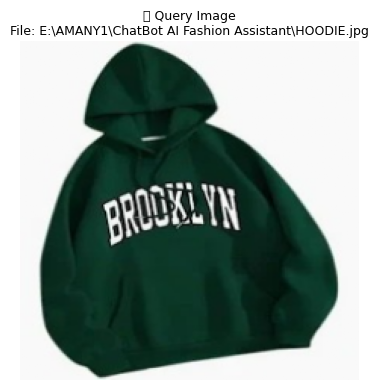

In [102]:
# ══════════════════════════════════════════════════════════════════════════════
# USER IMAGE UPLOAD
# ══════════════════════════════════════════════════════════════════════════════

# ── Option A: Upload a local image file ───────────────────────────────────────
# Set this to the path of your product image:
USER_IMAGE_PATH = Path("E:\AMANY1\ChatBot AI Fashion Assistant\HOODIE.jpg")          # e.g., "my_shirt.jpg"  or  "/path/to/dress.png"

# ── Option B: Use a URL ───────────────────────────────────────────────────────
# Set this to a product image URL (leave None if using Option A):
USER_IMAGE_URL  = None          # e.g., "https://example.com/product.jpg"

# ── Option C: Use a random dataset product (demo mode) ────────────────────────
DEMO_PRODUCT_ID = None          # e.g., 42   (None = pick random from dataset)

# ══════════════════════════════════════════════════════════════════════════════

if USER_IMAGE_PATH is not None:
    print(f"📁 Loading from file: {USER_IMAGE_PATH}")
    query_image = load_image_from_upload(USER_IMAGE_PATH)
    query_source = f"File: {USER_IMAGE_PATH}"

elif USER_IMAGE_URL is not None:
    print(f"🌐 Downloading from URL: {USER_IMAGE_URL}")
    query_image = load_image_from_url(USER_IMAGE_URL)
    query_source = f"URL: {USER_IMAGE_URL}"

else:
    # Demo mode — pick a random product from the dataset
    if DEMO_PRODUCT_ID is not None:
        demo_row = df[df["product_id"] == DEMO_PRODUCT_ID].iloc[0]
    else:
        demo_row    = df.sample(1, random_state=None).iloc[0]
    DEMO_PRODUCT_ID = demo_row["product_id"]

    # Try disk first, fall back to URL
    disk_path = Path(IMG_DIR) / f"{DEMO_PRODUCT_ID}.jpg"
    if disk_path.exists():
        query_image = load_image_from_disk(DEMO_PRODUCT_ID)
    else:
        query_image = load_image_from_url(str(demo_row["img_url"]))

    query_source  = f"Demo product_id={DEMO_PRODUCT_ID}: {demo_row['title_clean'][:50]}"
    print(f"🎲 Demo mode — using random product from dataset")
    print(f"   {query_source}")
    print()
    print(f"   Category : {demo_row.get('category_clean', 'N/A')}")
    print(f"   Price    : EGP {demo_row.get('price_egp', 'N/A')}")
    print(f"   Color    : {demo_row.get('primary_color', 'N/A')}")

print()
print(f"✅ Query image loaded — shape: {query_image.shape}")

# ── Preview the uploaded image ────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(query_image)
ax.set_title(f"🔍 Query Image\n{query_source[:60]}", fontsize=9, wrap=True)
ax.axis("off")
plt.tight_layout()
plt.show()


In [103]:
# ── Extract query embedding ───────────────────────────────────────────────────
print("⚙️  Extracting query image embedding...")
query_embedding = extract_embedding(query_image)
print(f"✅ Query embedding shape: {query_embedding.shape}")
print(f"   L2 norm (should be ~1.0): {np.linalg.norm(query_embedding):.4f}")
print()

# ── Cosine similarity search ──────────────────────────────────────────────────

def cosine_similarity_search(query_emb: np.ndarray,
                            db_embeddings: np.ndarray,
                            db_product_ids: np.ndarray,
                            top_k: int = TOP_K,
                            exclude_id: int = None,
                            faiss_idx=None) -> pd.DataFrame:
    """
    Find top-K most similar products using cosine similarity.

    Args:
        query_emb      : L2-normalised query embedding (1280,)
        db_embeddings  : L2-normalised product embeddings (N, 1280)
        db_product_ids : product ID array (N,)
        top_k          : number of results to return
        exclude_id     : product_id to exclude (if query IS a dataset product)
        faiss_idx      : optional FAISS index (faster for large datasets)

    Returns:
        DataFrame with columns: product_id, similarity_score
    """
    q = query_emb.reshape(1, -1).astype(np.float32)

    if faiss_idx is not None:
        # FAISS fast search (inner product = cosine on normalised vecs)
        k_search  = top_k + (1 if exclude_id is not None else 0)
        scores, indices = faiss_idx.search(q, k_search)
        scores    = scores[0]
        indices   = indices[0]
        # Filter out excluded product
        if exclude_id is not None:
            mask    = db_product_ids[indices] != exclude_id
            indices = indices[mask]
            scores  = scores[mask]
        results = pd.DataFrame({
            "product_id"      : db_product_ids[indices[:top_k]],
            "similarity_score": scores[:top_k]
        })

    else:
        # sklearn cosine similarity (O(N·D) — exact)
        sims = cosine_similarity(q, db_embeddings)[0]   # (N,)
        if exclude_id is not None:
            exclude_mask = (db_product_ids == exclude_id)
            sims[exclude_mask] = -1.0  # exclude from results
        top_indices = np.argsort(sims)[::-1][:top_k]
        results = pd.DataFrame({
            "product_id"      : db_product_ids[top_indices],
            "similarity_score": sims[top_indices]
        })

    return results.reset_index(drop=True)


# ── Run search ────────────────────────────────────────────────────────────────
print("🔎 Running similarity search...")
exclude = DEMO_PRODUCT_ID if (USER_IMAGE_PATH is None and USER_IMAGE_URL is None) else None

search_results = cosine_similarity_search(
    query_emb      = query_embedding,
    db_embeddings  = product_embeddings,
    db_product_ids = product_ids,
    top_k          = TOP_K,
    exclude_id     = exclude,
    faiss_idx      = faiss_index
)

print(f"✅ Search complete — top {TOP_K} matches found")
print()
print(search_results.to_string(index=False))


⚙️  Extracting query image embedding...
✅ Query embedding shape: (1280,)
   L2 norm (should be ~1.0): 1.0000

🔎 Running similarity search...
✅ Search complete — top 5 matches found

 product_id  similarity_score
        130          0.795505
         83          0.754592
       5274          0.696376
        158          0.695523
       5663          0.681439


## Section 12 — Retrieve Top Matches

> Merge similarity scores with full product metadata and generate caption for the query image.


In [104]:
# ── Generate caption for the query image ─────────────────────────────────────
print("🤖 Generating image caption...")
query_caption = generate_caption(captioning_model, query_image)
print(f"✅ Generated caption: '{query_caption}'")
print()

# ── Merge with product metadata ───────────────────────────────────────────────
retrieval_df = search_results.merge(df, on="product_id", how="left")

# ── Select display columns ────────────────────────────────────────────────────
display_columns = [
    "product_id", "similarity_score",
    "title_clean", "category_clean", "gender_clean",
    "price_egp", "price_bucket", "primary_color",
    "brand", "materials_str",
    "product_url", "img_url"
]
retrieval_df = retrieval_df[[c for c in display_columns if c in retrieval_df.columns]]

print("── Top Matches ──────────────────────────────────────────────────────────")
for i, row in retrieval_df.iterrows():
    print(f"  #{i+1}  [{row['similarity_score']:.4f}] {str(row.get('title_clean',''))[:60]}")
    print(f"       Category: {row.get('category_clean','N/A')} | "
        f"Price: EGP {row.get('price_egp','N/A')} | "
        f"Color: {row.get('primary_color','N/A')}")
    link = row.get('product_url', '')
    if link and str(link) != 'nan':
        print(f"       🔗 {str(link)[:800]}")
    print()


🤖 Generating image caption...
✅ Generated caption: 'hoodie oversize premium plain double layer cotton h 01 burgundy hoodies sweatshirts men mid range egp 450 0'

── Top Matches ──────────────────────────────────────────────────────────
  #1  [0.7955] V A L Y A Stylish Women Hoodie - Green
       Category: hoodies & sweatshirts | Price: EGP 349.99 | Color: green
       🔗 https://www.jumia.com.eg/v-a-l-y-a-stylish-women-hoodie-green-134052960.html

  #2  [0.7546] V A L Y A Stylish Women Hoodie - Fuchsia
       Category: hoodies & sweatshirts | Price: EGP 349.99 | Color: fuchsia
       🔗 https://www.jumia.com.eg/v-a-l-y-a-stylish-women-hoodie-fuchsia-134053337.html

  #3  [0.6964] Printed Hoodie Sweatshirt For Boys
       Category: hoodies & sweatshirts | Price: EGP 399.0 | Color: unknown
       🔗 https://www.jumia.com.eg/generic-printed-hoodie-sweatshirt-for-boys-116134840.html

  #4  [0.6955] V A L Y A Brown Hoodie for Women - Comfortable and Trendy
       Category: hoodies & sweatshirt

In [105]:
# ── Best matching product details ────────────────────────────────────────────
best = retrieval_df.iloc[0]

print("═" * 65)
print("🏆 BEST MATCHING PRODUCT")
print("═" * 65)
print(f"  Product ID   : {best.get('product_id')}")
print(f"  Name         : {best.get('title_clean', 'N/A')}")
print(f"  Category     : {best.get('category_clean', 'N/A')}")
print(f"  Gender       : {best.get('gender_clean', 'N/A')}")
print(f"  Price        : EGP {best.get('price_egp', 'N/A')}  ({best.get('price_bucket', 'N/A')})")
print(f"  Color        : {best.get('primary_color', 'N/A')}")
print(f"  Brand        : {best.get('brand', 'N/A')}")
print(f"  Material     : {best.get('materials_str', 'N/A')}")
print(f"  Similarity   : {best.get('similarity_score', 0):.4f}")
print(f"  Purchase Link: {best.get('product_url', 'N/A')}")
print("═" * 65)


═════════════════════════════════════════════════════════════════
🏆 BEST MATCHING PRODUCT
═════════════════════════════════════════════════════════════════
  Product ID   : 130
  Name         : V A L Y A Stylish Women Hoodie - Green
  Category     : hoodies & sweatshirts
  Gender       : women
  Price        : EGP 349.99  (mid-range)
  Color        : green
  Brand        : unknown
  Material     : unknown
  Similarity   : 0.7955
  Purchase Link: https://www.jumia.com.eg/v-a-l-y-a-stylish-women-hoodie-green-134052960.html
═════════════════════════════════════════════════════════════════


## Section 13 — Visualization & Final Results

> Side-by-side view of the query image, generated caption, and the top-5 similar products with full details and purchase links.


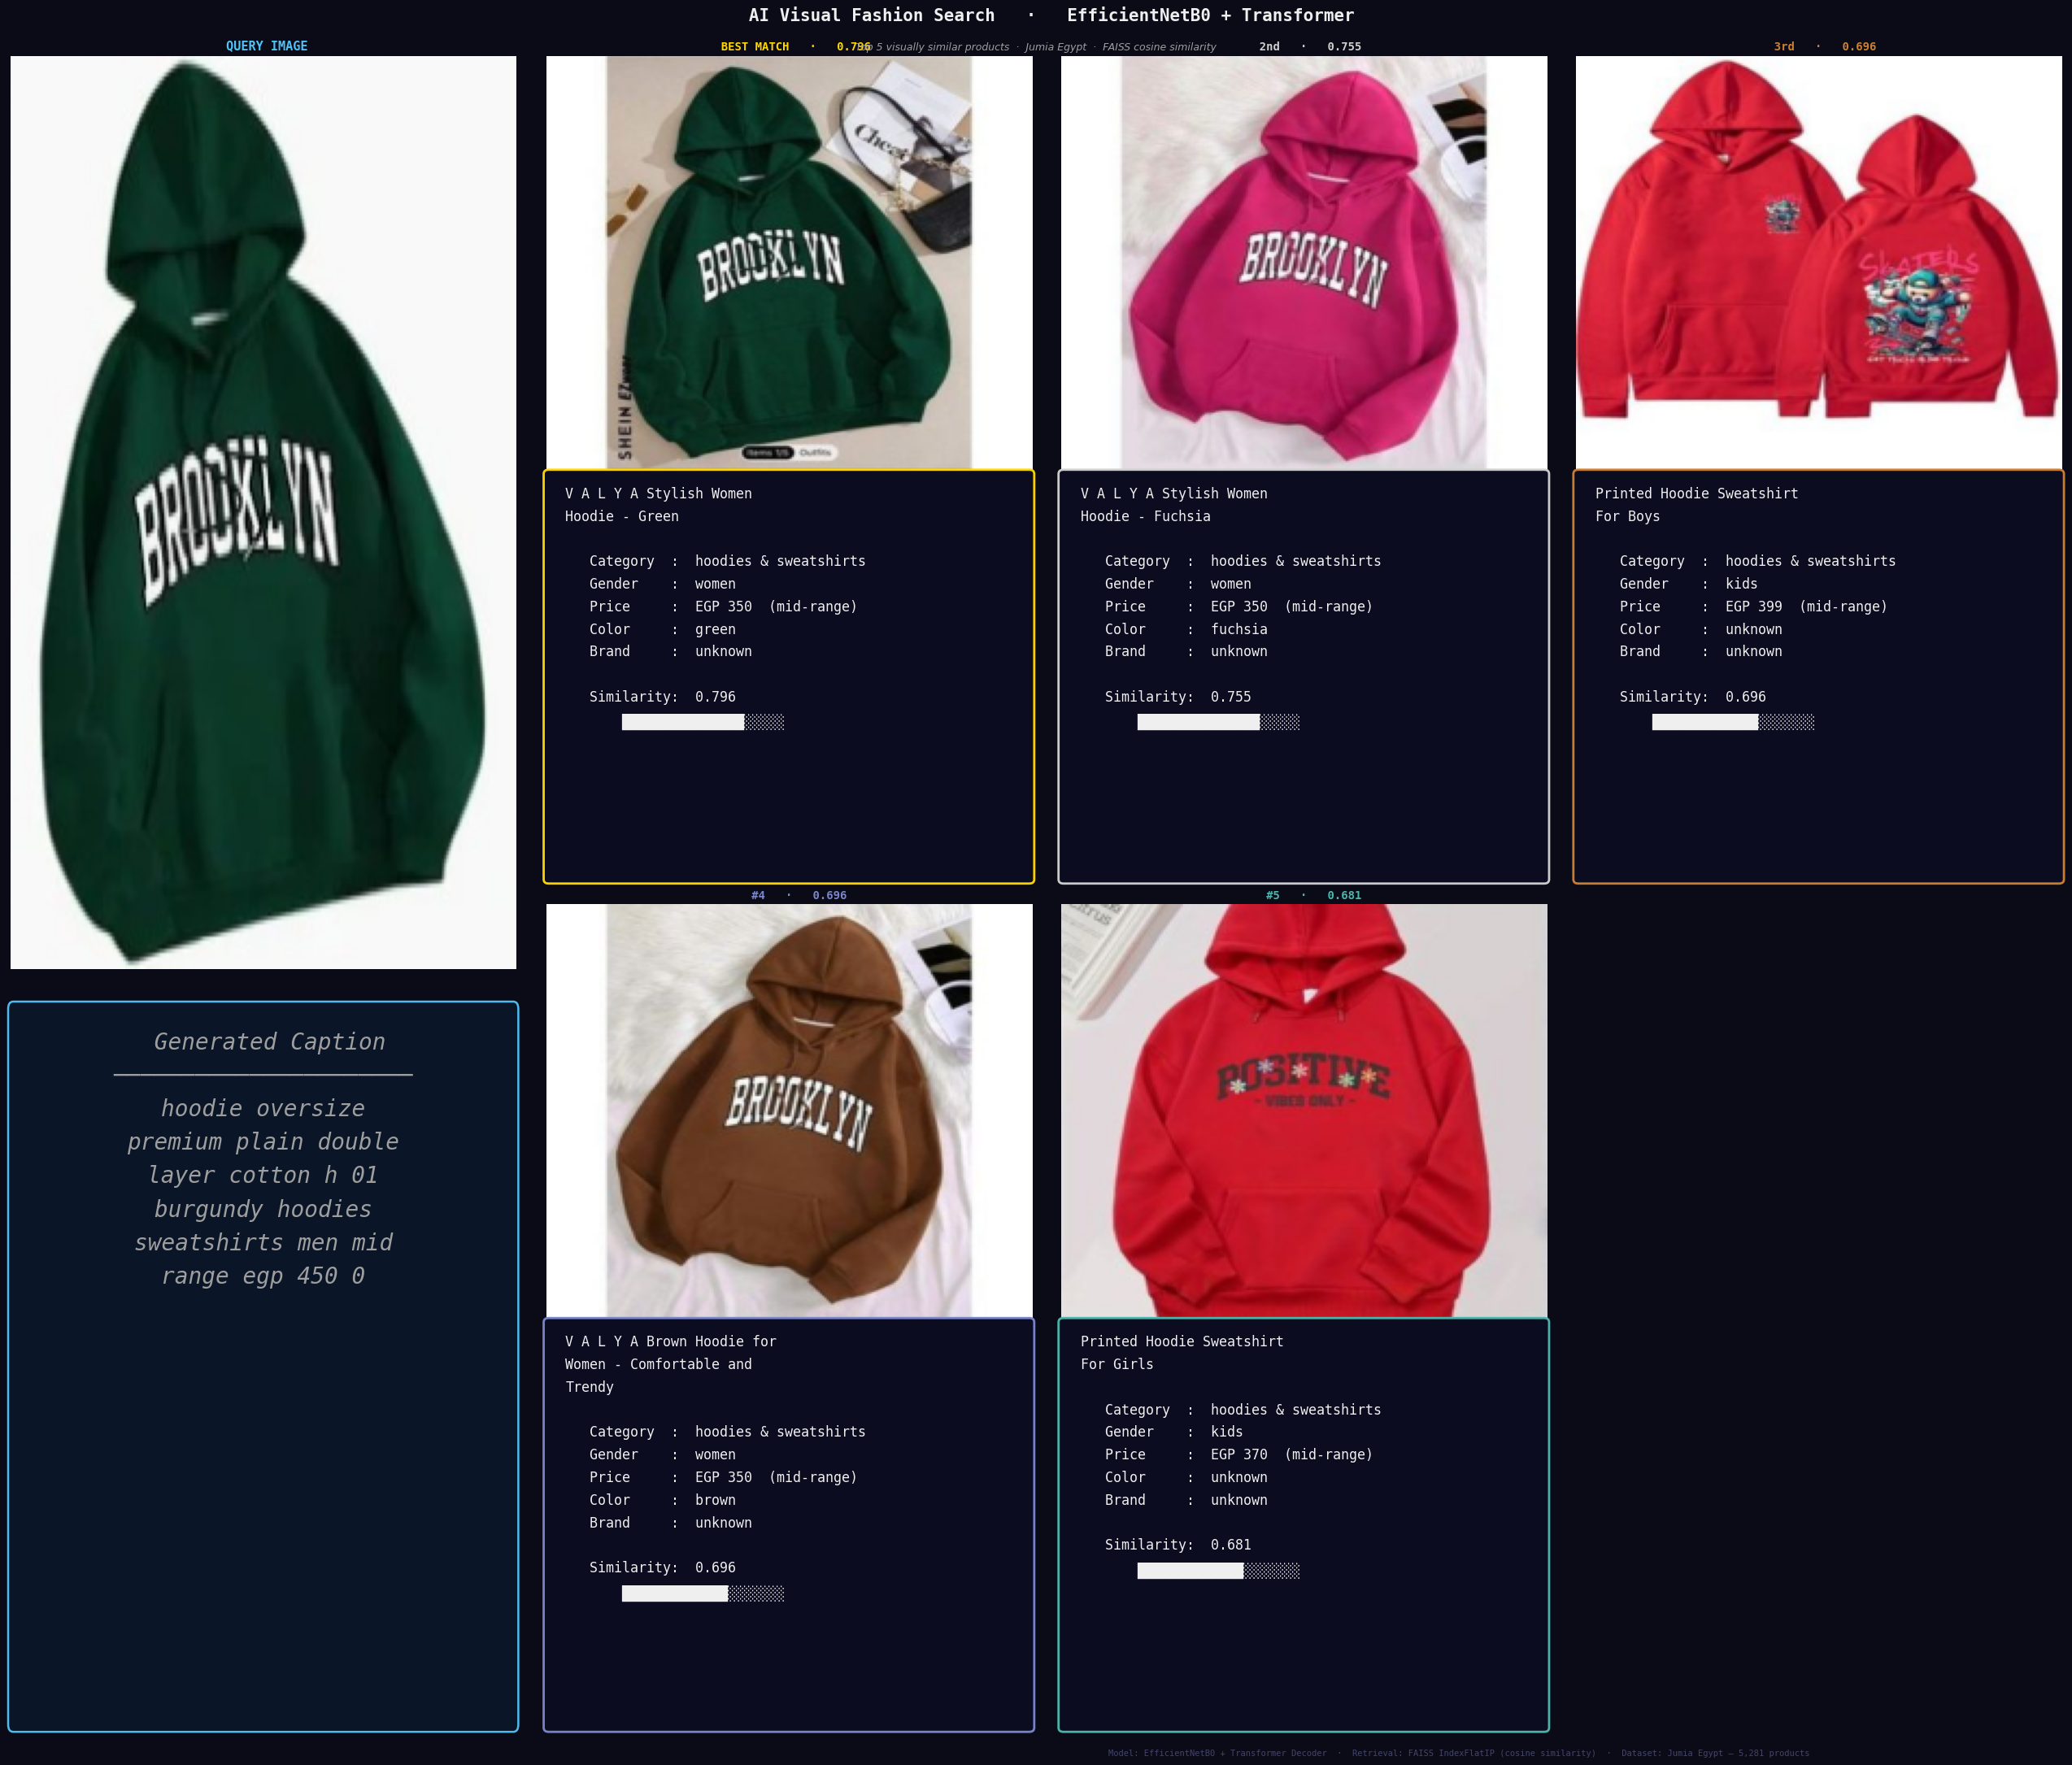


✅ Visualization saved → retrieval_results.png


In [106]:
# ══════════════════════════════════════════════════════════════════════════════
# FULL VISUALIZATION — AI Shopping Assistant (REDESIGNED v3)
# Bigger metadata boxes, all 6 images clearly visible
# ══════════════════════════════════════════════════════════════════════════════

import textwrap
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import FancyBboxPatch
import numpy as np
from pathlib import Path


def load_product_image(row: pd.Series) -> np.ndarray:
    """Load product image: disk → URL → grey placeholder."""
    pid  = row.get("product_id")
    url  = str(row.get("img_url", ""))
    path = Path(IMG_DIR) / f"{pid}.jpg"
    if path.exists():
        return load_image_from_disk(pid)
    elif url and url != "nan":
        return load_image_from_url(url)
    return np.ones((*IMG_SIZE, 3), dtype=np.float32) * 0.5


def visualize_results(query_img, query_caption, retrieval_df,
                    top_k=TOP_K, save_path="retrieval_results.png"):
    """
    Layout:
    ┌──────────────┬────────────┬────────────┬────────────┐
    │              │  [IMG 1]   │  [IMG 2]   │  [IMG 3]   │
    │  QUERY IMAGE │            │            │            │
    │              │ [META BOX] │ [META BOX] │ [META BOX] │
    │              ├────────────┼────────────┼────────────┤
    │  [CAPTION]   │  [IMG 4]   │  [IMG 5]   │  [empty]   │
    │              │            │            │            │
    │              │ [META BOX] │ [META BOX] │            │
    └──────────────┴────────────┴────────────┴────────────┘
    """
    n = min(top_k, len(retrieval_df))

    C_BG    = "#0b0b18"
    C_CARD  = "#13132a"
    C_BLUE  = "#4fc3f7"
    C_WHITE = "#efefef"
    C_GRAY  = "#9e9e9e"
    C_DIM   = "#44446a"

    RANKS = [
        ("#ffd700", "  BEST MATCH"),
        ("#d0d0d0", "  2nd"),
        ("#cd7f32", "  3rd"),
        ("#7986cb", "   #4"),
        ("#4db6ac", "   #5"),
    ]

    # ── Figure: tall enough for big metadata boxes ────────────────────────────
    fig = plt.figure(figsize=(26, 22), facecolor=C_BG)

    fig.text(0.5, 0.982,
             "   AI Visual Fashion Search   ·   EfficientNetB0 + Transformer",
             ha="center", va="top", fontsize=15, fontweight="bold",
             color=C_WHITE, fontfamily="monospace")
    fig.text(0.5, 0.963,
             f"Top {n} visually similar products  ·  Jumia Egypt  ·  FAISS cosine similarity",
             ha="center", va="top", fontsize=9,
             color=C_GRAY, fontstyle="italic")

    # ── Outer: left (query) | right (3 result cols) ──────────────────────────
    outer = GridSpec(
        1, 2,
        figure=fig,
        width_ratios=[1, 3],
        left=0.015, right=0.985,
        top=0.955, bottom=0.018,
        wspace=0.03
    )

    # ══ LEFT: query image + caption ══════════════════════════════════════════
    left_gs = GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=outer[0],
        height_ratios=[5, 4],           # ← was 2.5, now 4
        hspace=0.04
    )

    ax_q = fig.add_subplot(left_gs[0])
    ax_q.imshow(query_img, aspect="auto")
    ax_q.axis("off")
    ax_q.set_title(" QUERY IMAGE", color=C_BLUE,
                   fontsize=11, fontweight="bold",
                   fontfamily="monospace", pad=6)
    for sp in ax_q.spines.values():
        sp.set_visible(True)
        sp.set_edgecolor(C_BLUE)
        sp.set_linewidth(2.5)

    # ── Caption box — full-width FancyBboxPatch, fontsize 12 ─────────────────
    ax_cap = fig.add_subplot(left_gs[1])
    ax_cap.set_facecolor(C_BG)
    ax_cap.set_xlim(0, 1)
    ax_cap.set_ylim(0, 1)
    ax_cap.axis("off")

    caption_clean = query_caption.replace("<start>","").replace("<end>","").strip()
    wrapped = textwrap.fill(caption_clean, width=22)    # ← was 26

    cap_bg = FancyBboxPatch(
        (0.005, 0.01), 0.99, 0.98,
        boxstyle="round,pad=0.01",
        linewidth=1.8,
        edgecolor=C_BLUE,
        facecolor="#0a1628",
        transform=ax_cap.transAxes,
        clip_on=False,
        zorder=0,
        alpha=0.97
    )
    ax_cap.add_patch(cap_bg)

    ax_cap.text(
        0.5, 0.96,
        f" Generated Caption\n{'─'*22}\n{wrapped}",
        transform=ax_cap.transAxes,
        ha="center", va="top",
        fontsize=20,                                    # ← was 9, now 12
        color=C_GRAY,
        fontstyle="italic", fontfamily="monospace",
        linespacing=1.6,
        zorder=1
    )

    # ══ RIGHT: 2 rows × 3 cols  (img row + meta row + gap + img row + meta row)
    right_gs = GridSpecFromSubplotSpec(
        5, 3,
        subplot_spec=outer[1],
        height_ratios=[4, 4, 0.2, 4, 4],
        hspace=0.0,
        wspace=0.06
    )

    img_rows  = [(0,0),(0,1),(0,2),(3,0),(3,1)]
    meta_rows = [(1,0),(1,1),(1,2),(4,0),(4,1)]

    for i in range(5):
        ir, ic = img_rows[i]
        mr, mc = meta_rows[i]
        rank_color, rank_label = RANKS[i]

        # ── IMAGE ─────────────────────────────────────────────────────────────
        ax_img = fig.add_subplot(right_gs[ir, ic])

        if i < n:
            row      = retrieval_df.iloc[i]
            prod_img = load_product_image(row)
            sim      = float(row.get("similarity_score", 0))

            ax_img.imshow(prod_img, aspect="auto")
            ax_img.axis("off")
            ax_img.set_title(f"{rank_label}   ·   {sim:.3f}",
                             color=rank_color, fontsize=10,
                             fontweight="bold", fontfamily="monospace", pad=5)
            for sp in ax_img.spines.values():
                sp.set_visible(True)
                sp.set_edgecolor(rank_color)
                sp.set_linewidth(2.5)

            # Similarity bar overlay
            bar = ax_img.inset_axes([0, 0.92, sim, 0.08])
            bar.set_facecolor(rank_color)
            bar.set_alpha(0.7)
            bar.axis("off")

        else:
            ax_img.set_facecolor(C_CARD)
            ax_img.axis("off")
            ax_img.text(0.5, 0.5, "─", ha="center", va="center",
                        color=C_DIM, fontsize=24)

        # ── METADATA BOX ──────────────────────────────────────────────────────
        ax_meta = fig.add_subplot(right_gs[mr, mc])
        ax_meta.set_facecolor("#0c0c20")
        ax_meta.set_xlim(0, 1)
        ax_meta.set_ylim(0, 1)
        ax_meta.axis("off")

        if i < n:
            row    = retrieval_df.iloc[i]
            rc, _  = RANKS[i]

            name   = str(row.get("title_clean",    "")).strip()
            cat    = str(row.get("category_clean", "N/A")).strip()
            gender = str(row.get("gender_clean",   "N/A")).strip()
            price  = row.get("price_egp", "N/A")
            bucket = str(row.get("price_bucket",   "")).strip()
            color  = str(row.get("primary_color",  "N/A")).strip()
            brand  = str(row.get("brand",          "N/A")).strip()
            sim    = float(row.get("similarity_score", 0))

            price_str    = (f"EGP {price:.0f}"
                            if isinstance(price, (int, float)) else f"EGP {price}")
            name_wrapped = textwrap.fill(name, width=28)

            filled  = int(sim * 20)
            bar_str = "█" * filled + "░" * (20 - filled)

            info = (
                f"{name_wrapped}\n\n"
                f"   Category  :  {cat}\n"
                f"   Gender    :  {gender}\n"
                f"   Price     :  {price_str}  ({bucket})\n"
                f"   Color     :  {color}\n"
                f"   Brand     :  {brand}\n\n"
                f"   Similarity:  {sim:.3f}\n"
                f"       {bar_str}"
            )

            # Full-width rounded rectangle background
            bg = FancyBboxPatch(
                (0.005, 0.01), 0.99, 0.98,
                boxstyle="round,pad=0.01",
                linewidth=2,
                edgecolor=rc,
                facecolor="#0d0d22",
                transform=ax_meta.transAxes,
                clip_on=False,
                zorder=0,
                alpha=0.98
            )
            ax_meta.add_patch(bg)

            # Text — left-aligned, full width
            ax_meta.text(
                0.04, 0.96, info,
                transform=ax_meta.transAxes,
                ha="left", va="top",
                fontsize=12,
                color=C_WHITE,
                fontfamily="monospace",
                linespacing=1.7,
                zorder=1
            )

    # ── Gap row between result rows (row index 2) ─────────────────────────────
    for c in range(3):
        ax_gap = fig.add_subplot(right_gs[2, c])
        ax_gap.set_facecolor(C_BG)
        ax_gap.axis("off")

    # ── Footer ────────────────────────────────────────────────────────────────
    fig.text(
        0.7, 0.004,
        "Model: EfficientNetB0 + Transformer Decoder  ·  "
        "Retrieval: FAISS IndexFlatIP (cosine similarity)  ·  "
        "Dataset: Jumia Egypt — 5,281 products",
        ha="center", va="bottom", fontsize=7.5,
        color=C_DIM, fontfamily="monospace"
    )

    plt.savefig(save_path, dpi=150,
                bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"\n✅ Visualization saved → {save_path}")


# ── Run ───────────────────────────────────────────────────────────────────────
visualize_results(query_image, query_caption, retrieval_df, top_k=TOP_K)